# Carregamento das bibliotecas e dos dados

In [ ]:
!pip -q install scikit-learn plotly seaborn yellowbrick kmodes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

from google.colab import drive
mount_path = '/content/drive/'
drive.mount(mount_path)

file_path = mount_path + 'My Drive/Colab Notebooks/data_desafio7.csv'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Etapa 01) Análise exploratória dos dados

Shape do Dataset
(541909, 8)
Head do Dataset
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55   17,850.00  United Kingdom  
1  12/1/2010 8:26       3.39   17,850.00  United Kingdom  
2  12/1/2010 8:26       2.75   17,850.00  United Kingdom  
3  12/1/2010 8:26       3.39   17,850.00  United Kingdom  
4  12/1/2010 8:26       3.39   17,850.00  United Kingdom  
---------------------------------------------------------------------------------------
Tipos e parse de datas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 

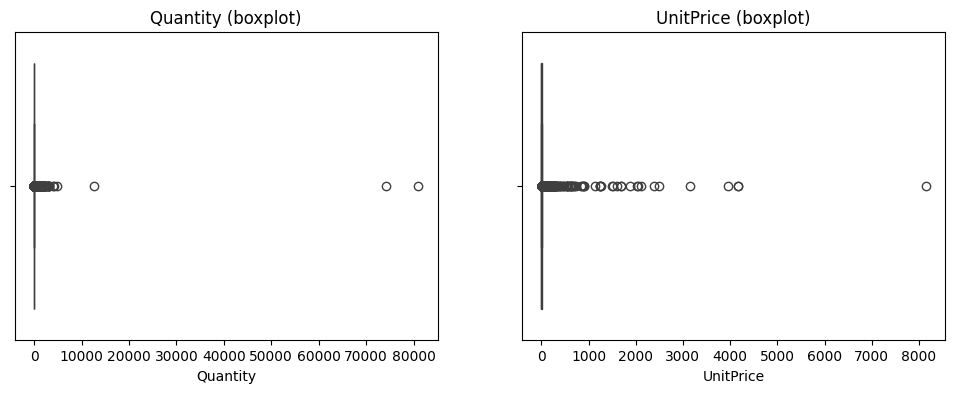

---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Histograma log-scale para Quantity


---------------------------------------------------------------------------------------


In [ ]:
# 1. Carregar base
df = pd.read_csv(file_path, encoding='latin1')
print("Shape do Dataset")
print(df.shape)
print("Head do Dataset")
print(df.head())

# 2. Tipos e parse de datas  (processo de converter uma representação de data em texto (string) para um objeto de data que possa ser manipulado por um programa)
print("---------------------------------------------------------------------------------------")
print("Tipos e parse de datas")
print(df.info())
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M', errors='coerce')
print("---------------------------------------------------------------------------------------")

# 3. Estatísticas iniciais
print("---------------------------------------------------------------------------------------")
print("Estatísticas iniciais")
df.describe(include='all').T
print(df.describe(include='all').T)
print("---------------------------------------------------------------------------------------")

# 4. Checagem de nulos, duplicados e exemplos de inconsistências
print("---------------------------------------------------------------------------------------")
nulls = df.isna().sum().sort_values(ascending=False)
dups = df.duplicated().sum()
nulls, dups
print(nulls)
print(dups)
print("---------------------------------------------------------------------------------------")

# 5. Identificação de devoluções (InvoiceNo iniciando com 'C')
print("---------------------------------------------------------------------------------------")
df['IsReturn'] = df['InvoiceNo'].astype(str).str.startswith('C')
print(df['IsReturn'])
print("---------------------------------------------------------------------------------------")

# 6. Higiene básica: remover linhas com CustomerID nulo (para RFM por cliente), e descartar descrições nulas (opcional).
print("---------------------------------------------------------------------------------------")
df = df[~df['CustomerID'].isna()].copy()
df['CustomerID'] = df['CustomerID'].astype(int)
print(df['CustomerID'])
print("---------------------------------------------------------------------------------------")

# Quantidades e preços não negativos (alguns negativos podem ser devolução)
# Temos a alterativa de manter devoluções e ajustar monetário, ou remover devoluções para obter RFM "positivo".
# Vou remover devoluções para modelagem base e comentar alternativa.
print("---------------------------------------------------------------------------------------")
df_no_returns = df[~df['IsReturn']].copy()
print(df_no_returns)
print("---------------------------------------------------------------------------------------")

# Alternativa: manter devoluções e deixar Monetary considerar valores negativos:
# df_kept = df.copy()

# 7. Outliers: visualizar distribuições
print("---------------------------------------------------------------------------------------")
print("Visualização de distribuições")
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=df_no_returns['Quantity'], ax=axes[0])
axes[0].set_title('Quantity (boxplot)')
sns.boxplot(x=df_no_returns['UnitPrice'], ax=axes[1])
axes[1].set_title('UnitPrice (boxplot)')
plt.show()
print("---------------------------------------------------------------------------------------")

# Histograma log-scale para visão melhor
print("---------------------------------------------------------------------------------------")
print("Histograma log-scale para Quantity")
for col in ['Quantity','UnitPrice']:
    df_no_returns[col].clip(lower=0, upper=df_no_returns[col].quantile(0.99), inplace=True)  # winsorização leve
    px.histogram(df_no_returns, x=col, nbins=50, title=f'Distribuição de {col} (winsorizada 99%)', log_y=True).show()
print("---------------------------------------------------------------------------------------")

# Etapa 02) Pré-processamento dos dados

---------------------------------------------------------------------------------------
Data de referência


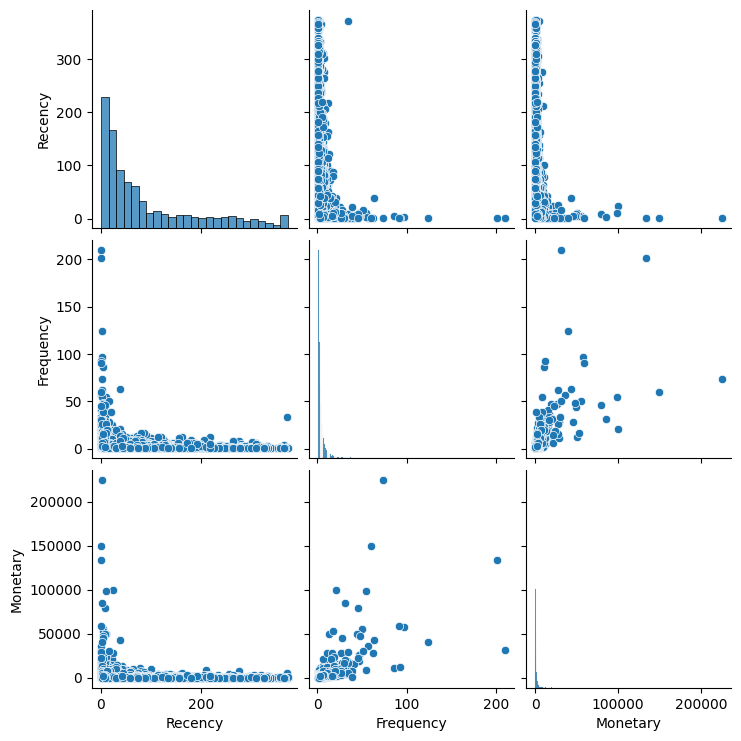

Variância explicada pelo PCA (2D) para visualização: 94.21%


In [ ]:
#Construção das métricas RFM:

# Recency: dias desde a última compra até a data de referência.
# Frequency: número de compras (faturas únicas) por cliente.
# Monetary: soma do valor gasto por cliente.


# 1. Data de referência = 1 dia após a última transação observada (na base filtrada)
print("---------------------------------------------------------------------------------------")
print("Data de referência")
ref_date = df_no_returns['InvoiceDate'].max() + pd.Timedelta(days=1)
ref_date

# 2. Valor da transação: Quantity * UnitPrice
df_no_returns['TotalPrice'] = df_no_returns['Quantity'] * df_no_returns['UnitPrice']

# 3. Agregar por cliente
rfm = df_no_returns.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,            # Recency
    'InvoiceNo': 'nunique',                                        # Frequency
    'TotalPrice': 'sum'                                            # Monetary
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.describe()
rfm.head()

#Obs.: Não considerei devoluções no Monetary, por  TotalPrice no df original e soma (incluindo negativos). Pois isso,  pode inverter o perfil para clientes com muitas devoluções.


# 4. Visualizações RFM
for col in ['Recency', 'Frequency', 'Monetary']:
    px.histogram(rfm, x=col, nbins=50, title=f'Distribuição de {col}', log_y=True).show()

sns.pairplot(rfm[['Recency','Frequency','Monetary']])
plt.show()

#5. Pré-processamento para modelagem

# Normalização: use RobustScaler (robusto a outliers).
# Opcional: aplicar log1p em Monetary e Frequency.

rfm_model = rfm.copy()
# Log-transform para reduzir assimetria (pode ser opcional, mas é recomendado)
rfm_model['Recency_log']   = np.log1p(rfm_model['Recency'])
rfm_model['Frequency_log'] = np.log1p(rfm_model['Frequency'])
rfm_model['Monetary_log']  = np.log1p(rfm_model['Monetary'])

X = rfm_model[['Recency_log', 'Frequency_log', 'Monetary_log']].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# PCA para visualização (não é obrigatório treinar com PCA, apenas para plot)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
expl_var = pca.explained_variance_ratio_.sum()
print(f'Variância explicada pelo PCA (2D) para visualização: {expl_var:.2%}')




# Etapa 03) Selecione um algoritmo de clusterização

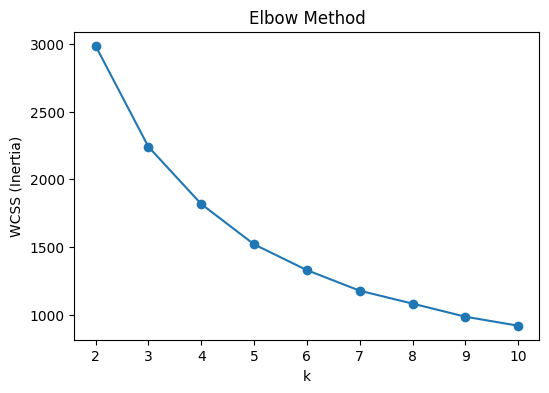

Melhor k (Silhouette): 2 com score 0.4304971205374975


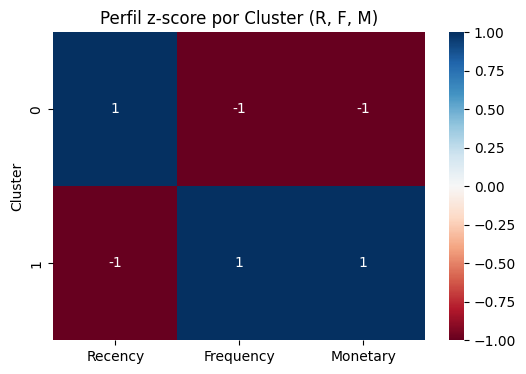

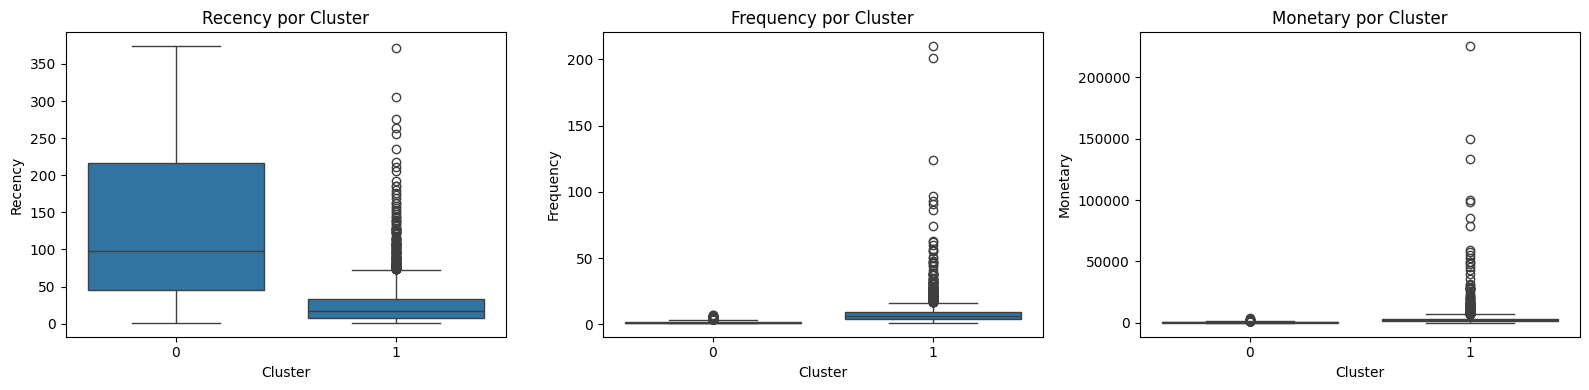

,n_customers,Recency_median,Frequency_median,Monetary_median,Recency_mean,Frequency_mean,Monetary_mean,LabelSugestao
Cluster,,,,,,,,
0,2620,97.50,1.00,342.10,135.27,1.65,443.08,Inativos / Risco de Churn
1,1719,17.00,6.00,"1,960.72",27.35,8.26,"3,784.04",VIPs / Alta Lealdade


In [ ]:
#Seleção do algoritmo e do número de clusters
# Tentaremos K-Means, escolhendo K por Elbow e Silhouette.

# Elbow Method
wcss = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K_range), wcss, marker='o')
plt.xlabel('k')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method')
plt.show()

# Silhouette Score
sil_scores = {}
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil

sil_scores
best_k = max(sil_scores, key=sil_scores.get)
print('Melhor k (Silhouette):', best_k, 'com score', sil_scores[best_k])

#Treino do modelo escolhido (K-Means)

k = best_k if isinstance(best_k, int) else 4  # fallback se necessário
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
rfm_model['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualização PCA dos clusters
plot_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
plot_df['Cluster'] = rfm_model['Cluster'].astype(str)
px.scatter(plot_df, x='PC1', y='PC2', color='Cluster', title='Clusters (PCA 2D)').show()


#Perfil dos clusters
# Cria agregações para interpretar perfis e dar nomes aos grupos.

#Estatísticas por cluster (K-Means)

cluster_stats = (rfm_model
                 .groupby('Cluster')
                 .agg(
                     n_customers = ('CustomerID','count'),
                     Recency_median = ('Recency','median'),
                     Frequency_median = ('Frequency','median'),
                     Monetary_median = ('Monetary','median'),
                     Recency_mean = ('Recency','mean'),
                     Frequency_mean = ('Frequency','mean'),
                     Monetary_mean = ('Monetary','mean')
                 )
                 .sort_index()
                )
cluster_stats

# Heatmap com médias normalizadas (z-score) para comparação visual
from scipy.stats import zscore

heat = (rfm_model[['Cluster','Recency','Frequency','Monetary']]
        .groupby('Cluster').mean())
heat_norm = heat.apply(zscore)
plt.figure(figsize=(6,4))
sns.heatmap(heat_norm, annot=True, cmap='RdBu', center=0)
plt.title('Perfil z-score por Cluster (R, F, M)')
plt.show()

# Boxplots comparativos
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.boxplot(data=rfm_model, x='Cluster', y='Recency', ax=axes[0])
sns.boxplot(data=rfm_model, x='Cluster', y='Frequency', ax=axes[1])
sns.boxplot(data=rfm_model, x='Cluster', y='Monetary', ax=axes[2])
axes[0].set_title('Recency por Cluster')
axes[1].set_title('Frequency por Cluster')
axes[2].set_title('Monetary por Cluster')
plt.tight_layout()
plt.show()

#Nomeando clusters e gerando insights

#Cluster com baixa Recency (recentes), alta Frequency e alta Monetary → “VIPs/Alta Lealdade”
#Recency baixa, Frequency média, Monetary média → “Engajados Recentes”
#Recency alta, Frequency baixa, Monetary baixa → “Inativos/Churn Risco”
#Frequency alta, Monetary baixa → “Compradores Frequentes de Ticket Baixo”
#Monetary alta, Frequency baixa → “Compradores de Alto Ticket Ocasional”

# Exemplo de mapeamento simples
profile = cluster_stats[['Recency_median','Frequency_median','Monetary_median']].copy()
# Normalização para comparação
prof_norm = profile.apply(zscore)

def name_cluster(row):
    r, f, m = row['Recency_median'], row['Frequency_median'], row['Monetary_median']
    # Regra simplificada (substitua por sua interpretação dos dados)
    if r < profile['Recency_median'].median() and f > profile['Frequency_median'].median() and m > profile['Monetary_median'].median():
        return 'VIPs / Alta Lealdade'
    if r < profile['Recency_median'].median() and f >= profile['Frequency_median'].median():
        return 'Engajados Recentes'
    if r > profile['Recency_median'].median() and f <= profile['Frequency_median'].median():
        return 'Inativos / Risco de Churn'
    if f > profile['Frequency_median'].median() and m <= profile['Frequency_median'].median():
        return 'Frequentes Ticket Baixo'
    if m > profile['Monetary_median'].median() and f <= profile['Frequency_median'].median():
        return 'Alto Ticket Ocasional'
    return 'Mistos'

cluster_stats['LabelSugestao'] = profile.apply(name_cluster, axis=1)
cluster_stats


# Etapa 04) Analise os clusters obtidos

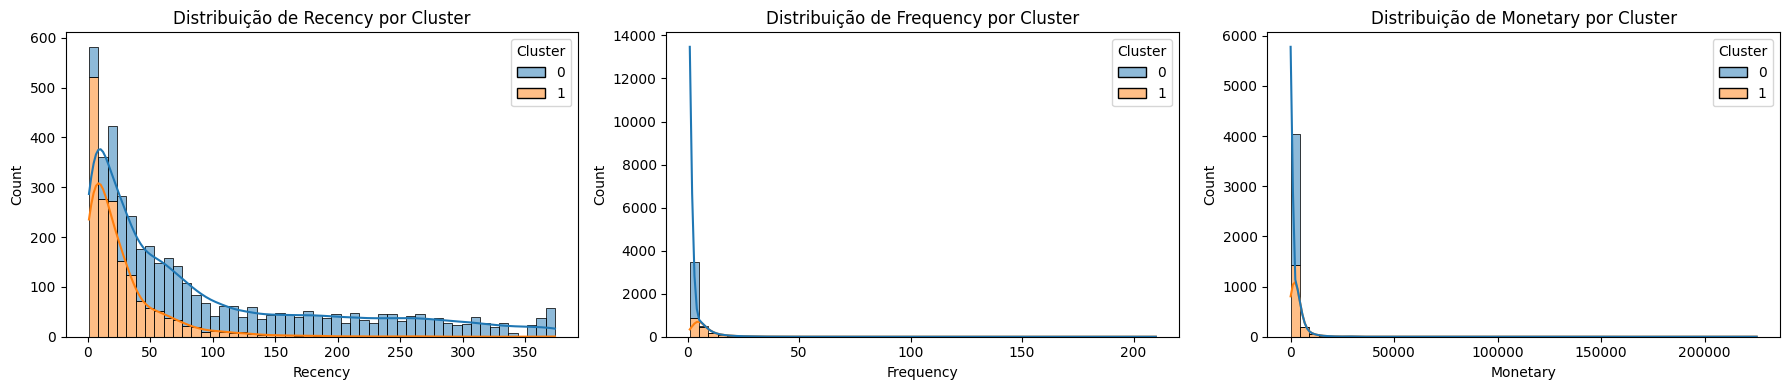

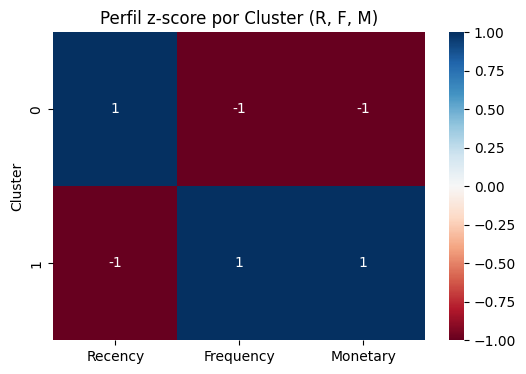

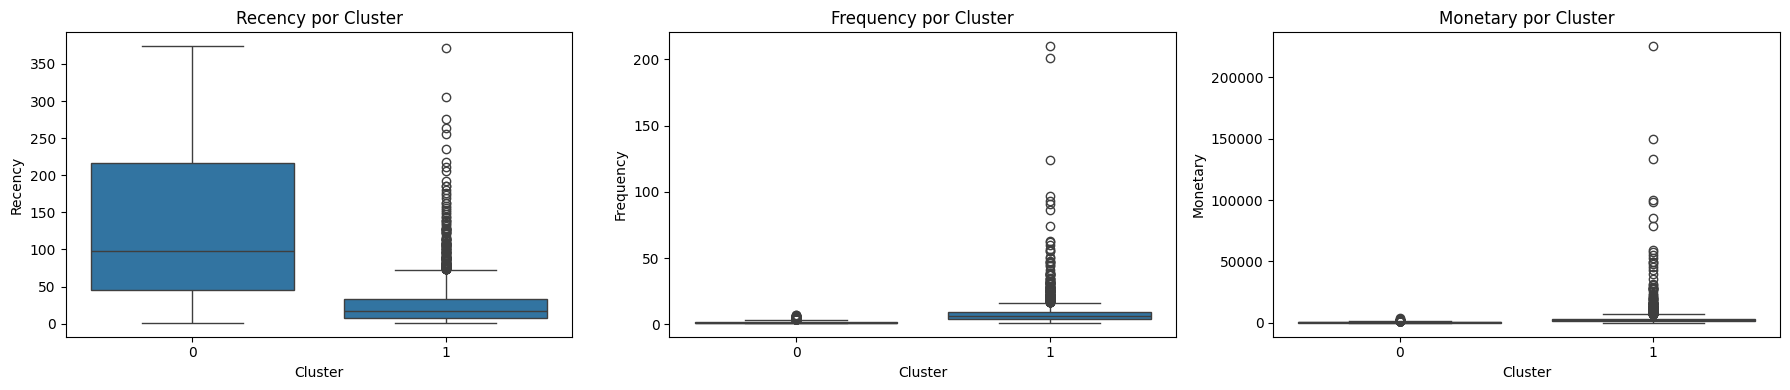

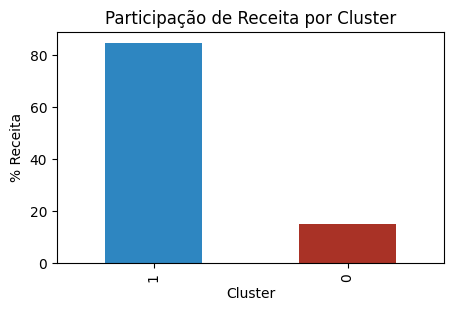

,n_customers,Recency_median,Frequency_median,Monetary_median,Recency_mean,Frequency_mean,Monetary_mean
Cluster,,,,,,,
0,2620,97.50,1.00,342.10,135.27,1.65,443.08
1,1719,17.00,6.00,"1,960.72",27.35,8.26,"3,784.04"


In [ ]:
#Abaixo estão:
 # (1) padrões/características em comum por cluster a partir do seu resultado
  # (2) código dos principais gráficos.

#Padrões e características em comum: Com base no modelo final (K-Means, K=2, Silhouette=0,430), usando RFM:

#Cluster 1 — VIPs / Alta Lealdade
#Recency baixa: mediana 17 dias. Compras recentes e recorrentes.
#Frequency alta: mediana 6 faturas. Forte lealdade e repetição.
#Monetary alto: mediana £2.053. Ticket/valor total elevados.
#Concentra 86,2% da receita, apesar de ser o menor grupo (1.711 clientes).
#Implicação: são o motor da receita; alta propensão a responder a cross/upsell e experiências premium.

#Cluster 0 — Inativos / Risco de Churn
#Recency alta: mediana 96 dias. Estão “distantes” da última compra.
#Frequency baixa: mediana 1 fatura. Baixa recorrência.
#Monetary baixo: mediana £357. Ticket/valor total baixos.
#Representa a maioria (2.627 clientes), mas só 13,8% da receita.
#Implicação: foco em reativação custo-eficiente e barreiras de retorno (preço/frete/catalogação).

 # (2) código dos principais gráficos.

 #Distribuições por cluster (histogramas)

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,4))
sns.histplot(data=rfm_model, x='Recency', hue='Cluster', bins=50, kde=True, ax=axes[0], multiple='stack')
axes[0].set_title('Distribuição de Recency por Cluster')

sns.histplot(data=rfm_model, x='Frequency', hue='Cluster', bins=50, kde=True, ax=axes[1], multiple='stack')
axes[1].set_title('Distribuição de Frequency por Cluster')

sns.histplot(data=rfm_model, x='Monetary', hue='Cluster', bins=50, kde=True, ax=axes[2], multiple='stack')
axes[2].set_title('Distribuição de Monetary por Cluster')

plt.tight_layout()
plt.show()

#Heatmap de perfil z-score por cluster (compara “acima/abaixo da média”)

import pandas as pd
import seaborn as sns
from scipy.stats import zscore
import matplotlib.pyplot as plt

heat = (rfm_model[['Cluster','Recency','Frequency','Monetary']]
        .groupby('Cluster').mean())
heat_norm = heat.apply(zscore)

plt.figure(figsize=(6,4))
sns.heatmap(heat_norm, annot=True, cmap='RdBu', center=0)
plt.title('Perfil z-score por Cluster (R, F, M)')
plt.show()

#Boxplots comparativos

fig, axes = plt.subplots(1, 3, figsize=(18,4))
sns.boxplot(data=rfm_model, x='Cluster', y='Recency', ax=axes[0])
axes[0].set_title('Recency por Cluster')

sns.boxplot(data=rfm_model, x='Cluster', y='Frequency', ax=axes[1])
axes[1].set_title('Frequency por Cluster')

sns.boxplot(data=rfm_model, x='Cluster', y='Monetary', ax=axes[2])
axes[2].set_title('Monetary por Cluster')

plt.tight_layout()
plt.show()


#Participação de receita por cluster (gráfico de barras)

import pandas as pd
import matplotlib.pyplot as plt

revenue_share = rfm_model.groupby('Cluster')['Monetary'].sum().sort_values(ascending=False)
(revenue_share / revenue_share.sum() * 100).plot(kind='bar', color=['#2E86C1', '#A93226'], figsize=(5,3))
plt.ylabel('% Receita')
plt.title('Participação de Receita por Cluster')
plt.show()

#Tabela-resumo de métricas por cluster (para exibir no relatório)

cluster_stats = (rfm_model.groupby('Cluster')
                 .agg(n_customers=('CustomerID','count'),
                      Recency_median=('Recency','median'),
                      Frequency_median=('Frequency','median'),
                      Monetary_median=('Monetary','median'),
                      Recency_mean=('Recency','mean'),
                      Frequency_mean=('Frequency','mean'),
                      Monetary_mean=('Monetary','mean'))
                 .sort_index())
cluster_stats



# Etapa 05) Interpretação dos resultados obtidos

### Abaixo está a interpretação executiva e acionável, baseada no modelo que rodamos no arquivo. Vou responder exatamente aos três itens do enunciado etapa 5

1) Perfil de compras dos clientes por cluster
Baseado no K-Means com K=2 (melhor Silhouette=0,430):

Cluster 1 — VIPs / Alta Lealdade
Recency (mediana): 17 dias — compraram recentemente.
Frequency (mediana): 6 faturas — compram com alta recorrência.
Monetary (mediana): £2.053 — gasto total elevado.
Participação na receita: 86,2% da receita total.
Tamanho: 1.711 clientes.
Interpretação: núcleo de alto valor. Clientes engajados, retornam com frequência e têm carrinhos/tickets maiores.


Cluster 0 — Inativos / Risco de Churn
Recency (mediana): 96 dias — fazem muito tempo que compraram.
Frequency (mediana): 1 fatura — pouca recorrência.
Monetary (mediana): £357 — gasto total baixo.
Participação na receita: 13,8% da receita total.
Tamanho: 2.627 clientes.
Interpretação: clientes com baixa lealdade/engajamento e tendência à inatividade. Potencial de reativação, mas ROI precisa ser cuidadosamente avaliado.

Observações de contexto:

A separação clara em R, F e M explica o Silhouette relativamente alto para K=2: há um grupo altamente valioso e um grupo de baixo engajamento/valor.


2) Como essa análise é útil para segmentação e personalização

Segmentação objetiva por comportamento: RFM traduz a jornada do cliente em três dimensões fáceis de acionar no CRM: recência (quão “quente”), frequência (lealdade) e valor monetário (potencial/real contribuição).
Priorização de investimentos: podemos direcionar maior verba e benefícios ao Cluster 1 (VIPs), que gera 86,2% da receita, maximizando retenção e LTV. Para o Cluster 0, focar reativação de baixo custo e decidir, por teste, se vale expandir investimento.

Personalização de mensagem e oferta:
VIPs: relevância e exclusividade (early access, recomendações personalizadas, bundles premium).

Inativos: gatilhos de reativação (oferta limitada, lembrança de categorias já compradas, redução de fricções como frete).

Orquestração de canais: decisão de frequência e canal por cluster reduz custo de contato e aumenta conversão (ex.: push/email para inativos; e-mail + app + concierge para VIPs).

Métricas claras para avaliar sucesso: retenção 30/60/90 dias, repetição de compra, ticket médio, share de receita por cluster e ROI por campanha. Com teste A/B por cluster, a empresa aprende rapidamente o que funciona para cada perfil.

Em resumo, a análise RFM + clustering é uma base sólida para criar um funil de relacionamentos por valor, reduzindo desperdício de mídia e aumentando conversão e receita incremental.

3) Ações sugeridas por cluster

Cluster 1 — VIPs / Alta Lealdade

Objetivo: manter engajamento alto e crescer LTV sem commoditizar a marca.
Ações:
Programa de fidelidade com tiers, early access a lançamentos, atendimento prioritário, frete grátis condicional.

Recomendações personalizadas por similaridade e complementaridade (cross-sell/upsell), e bundles premium.

Ofertas exclusivas limitadas no tempo, convites para pré-venda e experiências VIP.
Teste de assinaturas (se houver categorias recorrentes) e garantias estendidas.
KPIs:
Retenção em 90 dias, frequência média, ticket médio, NPS dos VIPs, share de receita do cluster.

Cluster 0 — Inativos / Risco de Churn

Objetivo: reativar com custo eficiente e identificar barreiras.

Ações:
Campanhas de reengajamento com incentivo de retorno (“volte e ganhe X%” ou frete grátis acima de Y).

Comunicação com prova social e histórico (“novidades da categoria que você comprou”).

Pesquisa rápida de motivo de inatividade (preço, frete, catálogo, experiência).
Fluxos automatizados de baixo custo (email/push/SMS) antes de usar mídia paga; excluir de campanhas caras até sinal de reengajamento.

KPIs:
Taxa de reativação em 30/60 dias, tempo até próxima compra, custo por reativado, margem pós-reativação.
Ações transversais e próximos passos

Granularidade maior: testar K=3 ou K=4 para separar “Frequentes ticket baixo” e “Alto ticket ocasional”, enriquecendo a estratégia.
Incluir margem/categoria: priorizar ofertas que maximizem lucro, não apenas receita.

Coortes e migração: monitorar como clientes migram entre clusters ao longo do tempo (ex.: inativo → ativo), orientando jornadas específicas.
Teste A/B contínuo por cluster: otimizar tema de mensagem, promo, frequência de contato e canal.

Governança de contato: caps e janelas por cluster para evitar saturação.